OPTIMASI PREDIKSI KONSUMSI DAYA LISTRIK MENGGUNAKAN METODE REGRESI

1. DATA UNDERSTANDING DAN LOAD DATA

In [1]:
import pandas as pd
import numpy as np

# Cell 1: Load Data dan Data Understanding
# Memuat data apa adanya (tanda '?' tetap dibaca sebagai '?' agar kita tahu kondisinya)
df = pd.read_csv('/content/drive/MyDrive/dataset ml/household_power_consumption.csv', low_memory=False)

# Menampilkan informasi dasar untuk melihat tipe data asli dari file
print("--- Info Dataset ---")
print(df.info())

# Melihat 5 data teratas untuk memahami format penulisan
print("\n--- 5 Data Teratas ---")
display(df.head())

# Melihat statistik deskriptif untuk melihat rentang nilai
print("\n--- Statistik Deskriptif ---")
display(df.describe(include='all'))

# Mengecek keberadaan simbol '?' di dalam dataset
print("\n--- Pengecekan Simbol '?' ---")
print(f"Jumlah baris dengan simbol '?': {(df == '?').sum().sum()}")

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB
None

--- 5 Data Teratas ---


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0



--- Statistik Deskriptif ---


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1048575,1048575,1048575,1048575,1048575,1048575,1048575,1048575,1.044506e+06
unique,729,1440,4076,492,2605,219,82,80,NaN
top,12/12/2008,20:05:00,0.218,0,?,1,0,0,NaN
freq,1440,729,6714,266300,4069,95350,958708,746737,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.933837e+00
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.210398e+00
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.700000e+01



--- Pengecekan Simbol '?' ---
Jumlah baris dengan simbol '?': 24414


2. DATA PRE-PROCESSING

In [2]:
import pandas as pd
import numpy as np

# 1. Menangani Missing Value
df.replace('?', np.nan, inplace=True)
print("Jumlah missing value sebelum handling:\n", df.isnull().sum())
df.ffill(inplace=True)
print("\nMissing value setelah ffill:", df.isnull().sum().sum())

# 2. Feature Engineering: Mengonversi Date & Time menjadi Datetime Index
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.set_index('Datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

# 3. Memastikan semua kolom bertipe float
df = df.astype(float)

# 4. Menambahkan fitur waktu (Sesuai saran sebelumnya yang sudah kita gunakan di EDA)
# Fitur ini bukan "mengarang", tapi mengekstrak informasi dari index Datetime
df['hour'] = df.index.hour

print("\nPreprocessing selesai. Fitur 'hour' telah tersedia.")
display(df.head())

Jumlah missing value sebelum handling:
 Date                        0
Time                        0
Global_active_power      4069
Global_reactive_power    4069
Voltage                  4069
Global_intensity         4069
Sub_metering_1           4069
Sub_metering_2           4069
Sub_metering_3           4069
dtype: int64

Missing value setelah ffill: 0

Preprocessing selesai. Fitur 'hour' telah tersedia.


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour
Datetime,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17


3. BOXPLOT

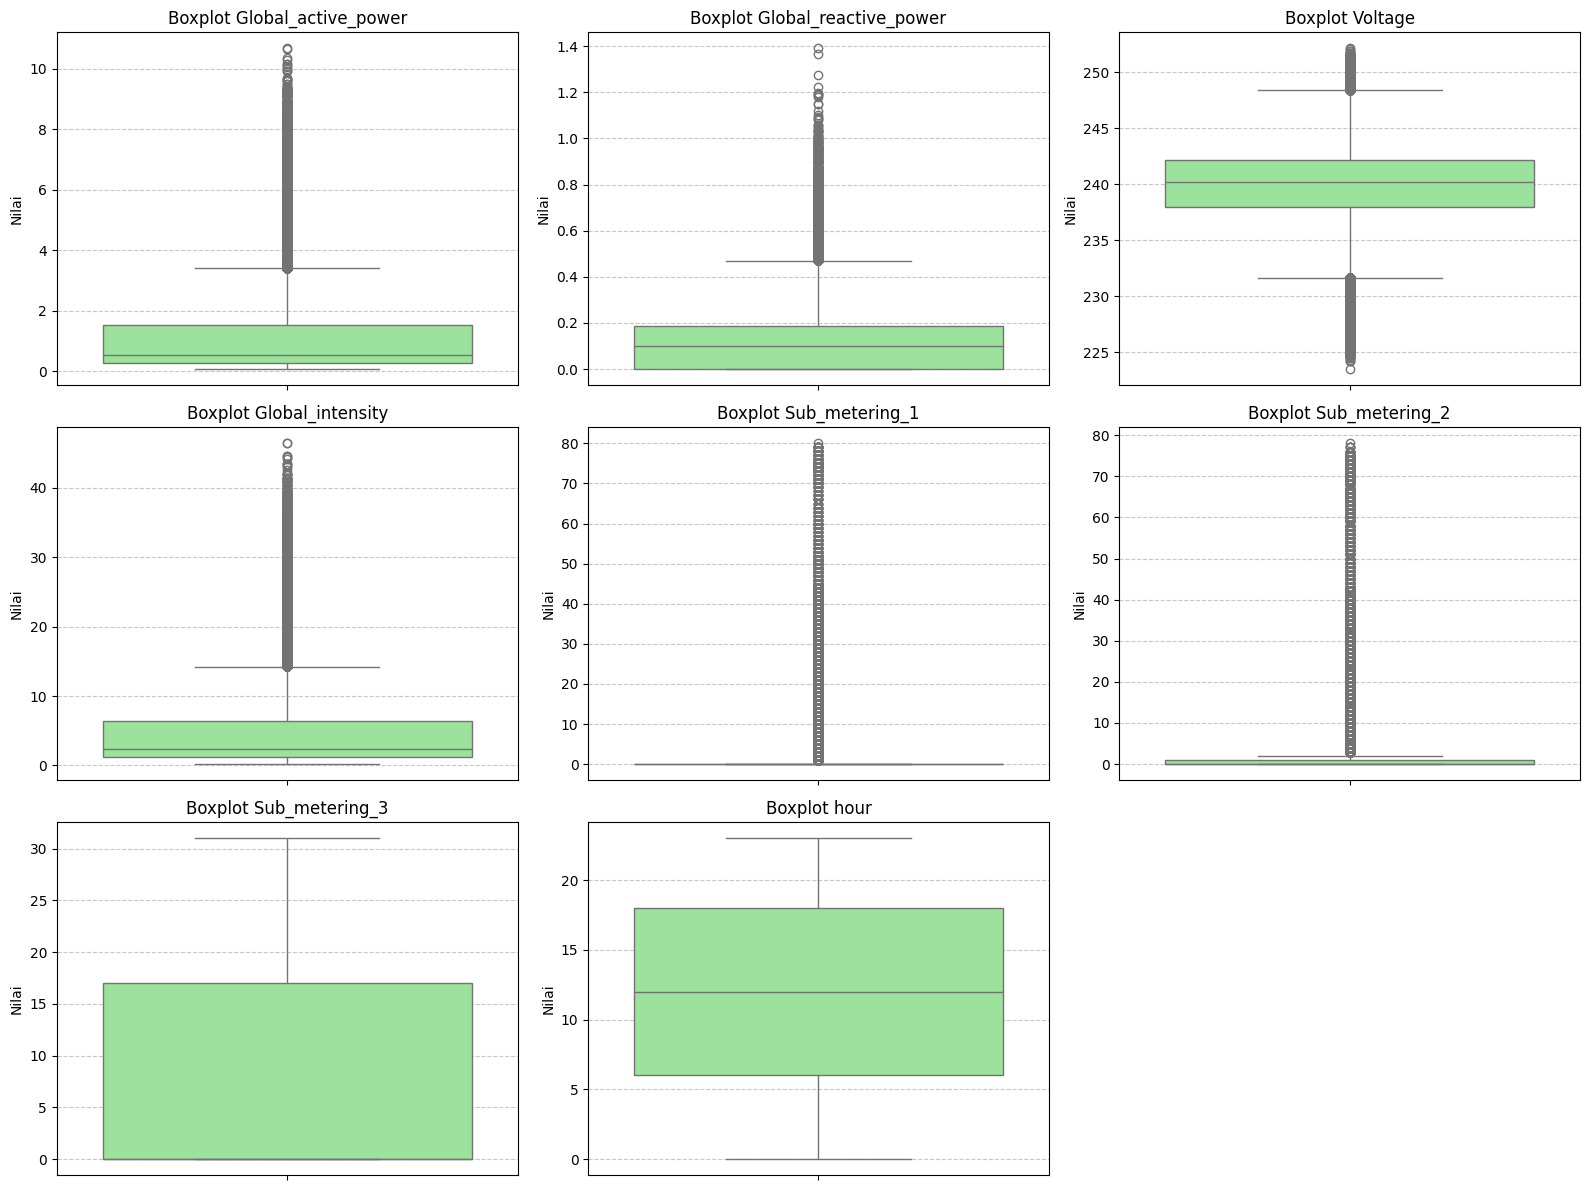

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daftar semua fitur yang kita gunakan
features = ['Global_active_power', 'Global_reactive_power', 'Voltage',
            'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
            'Sub_metering_3', 'hour']

# Menyiapkan area plot dengan ukuran yang cukup besar
plt.figure(figsize=(16, 12))

# Melakukan perulangan untuk membuat boxplot setiap fitur secara otomatis
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1) # Membuat layout 3 baris x 3 kolom
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot {col}', fontsize=12)
    plt.ylabel('Nilai')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

4. EXPLORATORY DATA ANALYSIS (EDA)

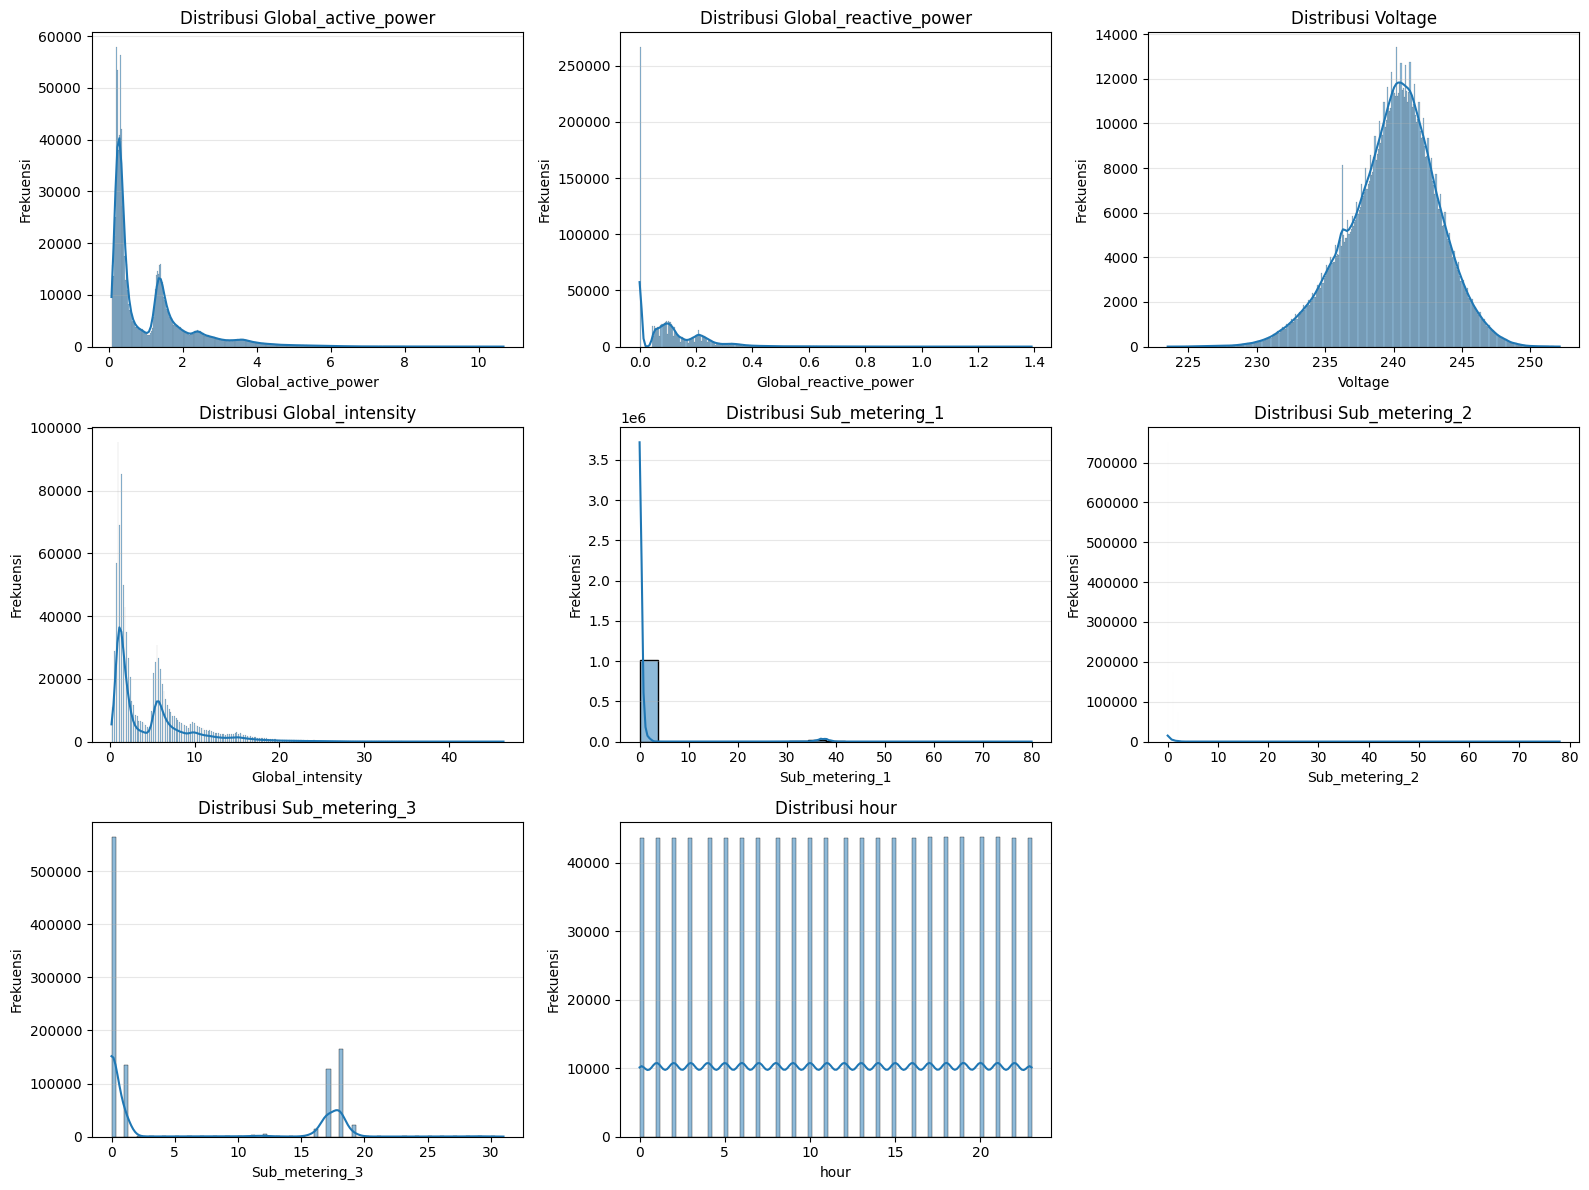

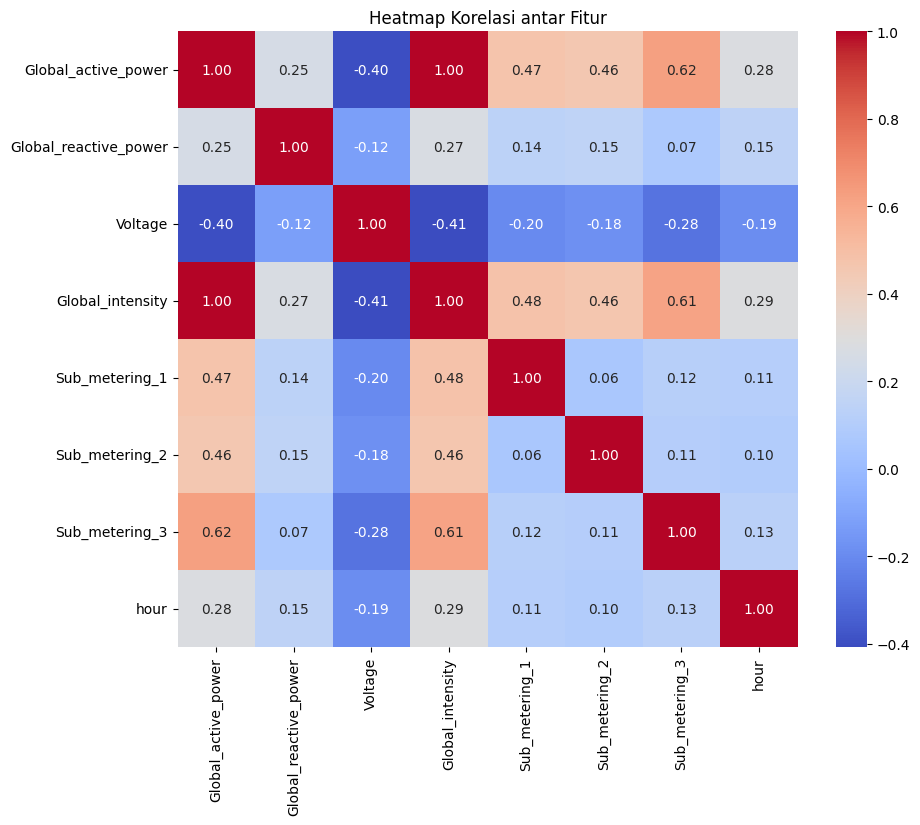

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daftar fitur (tanpa target kalau mau dipisah, tapi di sini kita tampilkan semua)
features = df.columns

# 1. Membuat plot distribusi untuk semua fitur
plt.figure(figsize=(16, 12))

for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)  # sesuaikan dengan jumlah fitur
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Korelasi antar Variabel (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi antar Fitur')
plt.show()

5. DATA SPLITTING

In [5]:
from sklearn.model_selection import train_test_split

# Menentukan Fitur (X) dan Target (y)
# Sesuai rencana regresi kita, target adalah Global_active_power
X = df.drop(['Global_active_power'], axis=1)
y = df['Global_active_power']

# Berdasarkan poin 2 dan 4 petunjuk tugas: Eksperimen 3 kombinasi rasio
ratios = [0.3, 0.2, 0.1] # Representasi 70:30, 80:20, 90:10
split_data = {}

for test_size in ratios:
    train_size_percent = int((1 - test_size) * 100)
    test_size_percent = int(test_size * 100)
    name = f"{train_size_percent}:{test_size_percent}"

    # Splitting tanpa shuffle untuk menjaga urutan waktu (Time Series)
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )

    split_data[name] = {
        'X_train': X_train_temp,
        'X_test': X_test_temp,
        'y_train': y_train_temp,
        'y_test': y_test_temp
    }

    print(f"Rasio {name} -> Train: {len(X_train_temp)} | Test: {len(X_test_temp)}")

# Untuk tahap awal pembangunan model, kita gunakan rasio 80:20 sebagai acuan utama
X_train, X_test = split_data["80:20"]['X_train'], split_data["80:20"]['X_test']
y_train, y_test = split_data["80:20"]['y_train'], split_data["80:20"]['y_test']

Rasio 70:30 -> Train: 734002 | Test: 314573
Rasio 80:20 -> Train: 838860 | Test: 209715
Rasio 90:10 -> Train: 943717 | Test: 104858


6. Model Building & Hyperparameter Tuning

In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Tahap Persiapan Fitur & Target (Seluruh Data) ---
X = df.drop(['Global_active_power'], axis=1)
y = df['Global_active_power']

# Feature Scaling tetap dilakukan untuk stabilitas model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Rasio pembagian sesuai persyaratan tugas
ratios = [(0.3, "70:30"), (0.2, "80:20"), (0.1, "90:10")]

results_list = []

for test_size, label in ratios:
    print(f"\n==== Eksperimen Rasio {label} (Menggunakan Seluruh Data) ====")

    # Splitting data (shuffle=False karena ini data deret waktu/time series)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, shuffle=False)

    # 1. Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    # 2. Decision Tree + Tuning
    # Menggunakan max_depth agar model tidak overfitting pada data yang besar
    dt = DecisionTreeRegressor(random_state=42)
    dt_param = {'max_depth': [10, 20]}
    dt_grid = GridSearchCV(dt, dt_param, cv=3, n_jobs=-1)
    dt_grid.fit(X_train, y_train)

    # 3. Random Forest + Tuning
    # Catatan: n_estimators dibatasi agar proses training tidak memakan waktu berjam-jam
    rf = RandomForestRegressor(random_state=42)
    rf_param = {'n_estimators': [50], 'max_depth': [10]}
    rf_grid = GridSearchCV(rf, rf_param, cv=2, n_jobs=-1) # cv=2 untuk mempercepat waktu komputasi
    rf_grid.fit(X_train, y_train)

    # List Model untuk Evaluasi
    trained_models = [
        ("Linear Regression", lr),
        ("Decision Tree (Tuned)", dt_grid.best_estimator_),
        ("Random Forest (Tuned)", rf_grid.best_estimator_)
    ]

    # Evaluasi & Penyimpanan Hasil
    for name, model in trained_models:
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)

        results_list.append({
            'Split_Ratio': label,
            'Algorithm': name,
            'R2_Score': r2,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse
        })
        print(f"Selesai: {name} | R2 Score: {r2:.4f}")

print("\nPelatihan pada seluruh data selesai!")


==== Eksperimen Rasio 70:30 (Menggunakan Seluruh Data) ====
Selesai: Linear Regression | R2 Score: 0.9983
Selesai: Decision Tree (Tuned) | R2 Score: 0.9984
Selesai: Random Forest (Tuned) | R2 Score: 0.9985

==== Eksperimen Rasio 80:20 (Menggunakan Seluruh Data) ====
Selesai: Linear Regression | R2 Score: 0.9986
Selesai: Decision Tree (Tuned) | R2 Score: 0.9988
Selesai: Random Forest (Tuned) | R2 Score: 0.9989

==== Eksperimen Rasio 90:10 (Menggunakan Seluruh Data) ====
Selesai: Linear Regression | R2 Score: 0.9988
Selesai: Decision Tree (Tuned) | R2 Score: 0.9990
Selesai: Random Forest (Tuned) | R2 Score: 0.9991

Pelatihan pada seluruh data selesai!


7. Model Comparison & Evaluation

--- Tabel Perbandingan Performa Model (Semua Skenario) ---


,Split_Ratio,Algorithm,R2_Score,MAE,MSE,RMSE
8,90:10,Random Forest (Tuned),0.999076,0.022775,0.001179,0.034342
7,90:10,Decision Tree (Tuned),0.999002,0.023642,0.001274,0.035696
5,80:20,Random Forest (Tuned),0.998868,0.024217,0.001205,0.034715
6,90:10,Linear Regression,0.998841,0.026527,0.001479,0.038463
4,80:20,Decision Tree (Tuned),0.998788,0.025088,0.001291,0.035933
3,80:20,Linear Regression,0.998648,0.026315,0.001440,0.037950
2,70:30,Random Forest (Tuned),0.998536,0.024622,0.001478,0.038443
1,70:30,Decision Tree (Tuned),0.998437,0.025413,0.001577,0.039711
0,70:30,Linear Regression,0.998299,0.026876,0.001717,0.041438


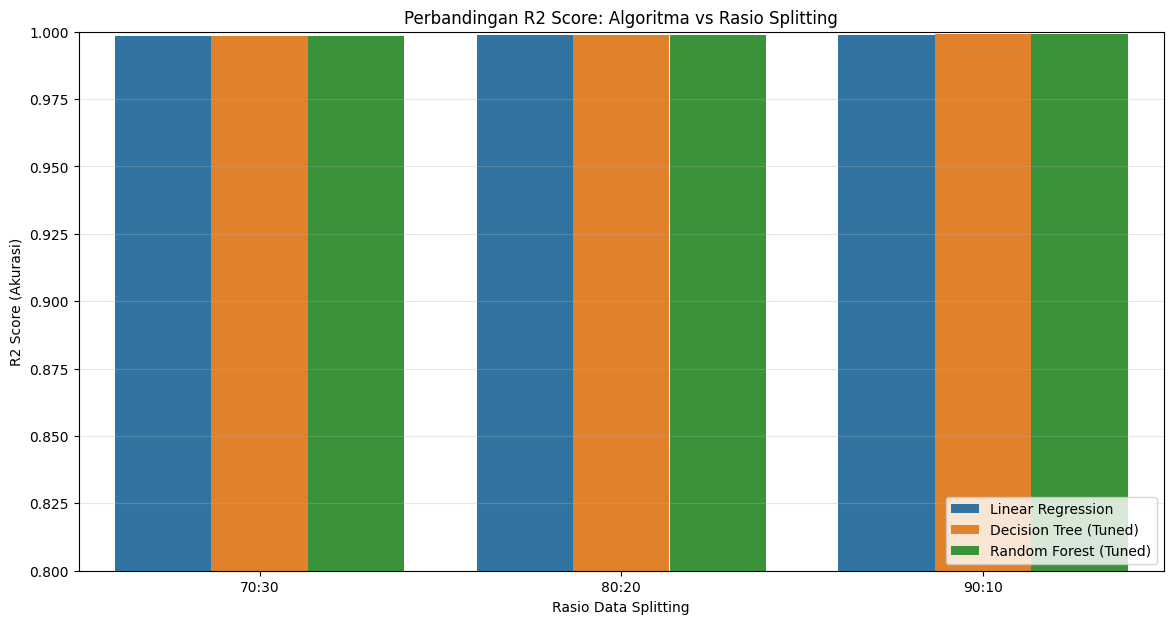


--- Ringkasan untuk Laporan ---
Berdasarkan eksperimen, skenario terbaik adalah menggunakan algoritma Random Forest (Tuned) dengan rasio splitting 90:10.
Hasil R2 Score: 0.9991


In [7]:
# 1. Membuat DataFrame dari hasil eksperimen
df_comparison = pd.DataFrame(results_list)

# 2. Menampilkan Tabel Perbandingan Lengkap (MAE, MSE, RMSE, R2)
print("--- Tabel Perbandingan Performa Model (Semua Skenario) ---")
display(df_comparison.sort_values(by=['R2_Score'], ascending=False))
df_comparison = df_comparison.round(4)

# 3. Visualisasi Perbandingan R2 Score antar Rasio Splitting
plt.figure(figsize=(14, 7))
sns.barplot(x='Split_Ratio', y='R2_Score', hue='Algorithm', data=df_comparison)
plt.title('Perbandingan R2 Score: Algoritma vs Rasio Splitting')
plt.ylabel('R2 Score (Akurasi)')
plt.xlabel('Rasio Data Splitting')
plt.ylim(0.8, 1.0) # Fokus pada rentang akurasi tinggi
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Kesimpulan untuk Laporan
best_row = df_comparison.loc[df_comparison['R2_Score'].idxmax()]
print("\n--- Ringkasan untuk Laporan ---")
print(f"Berdasarkan eksperimen, skenario terbaik adalah menggunakan algoritma {best_row['Algorithm']} "
      f"dengan rasio splitting {best_row['Split_Ratio']}.")
print(f"Hasil R2 Score: {best_row['R2_Score']:.4f}")

8. FEATURE IMPORTANT

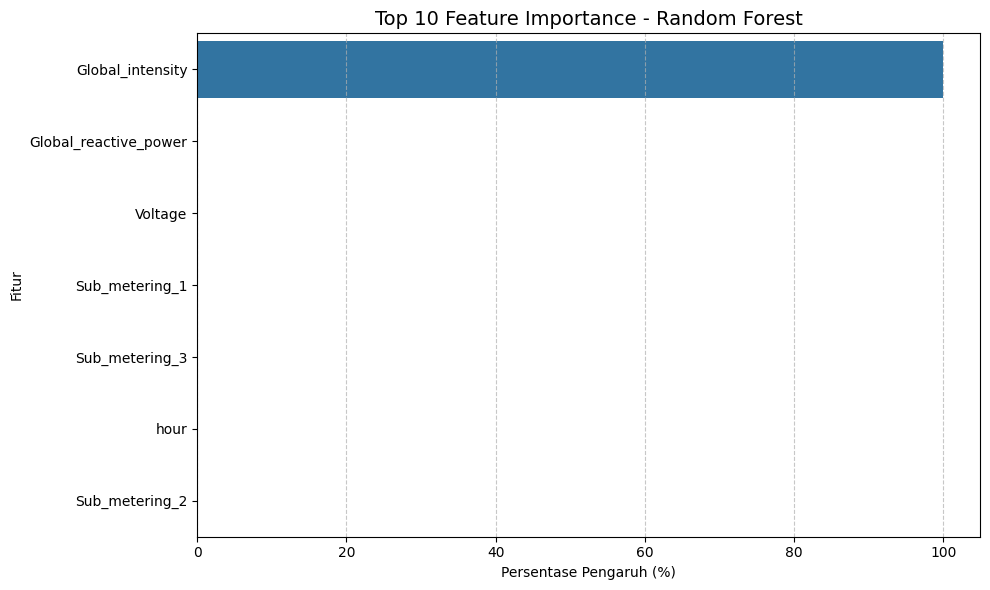


--- Top 7 Feature Importance ---


,Feature,Importance,Importance (%)
2,Global_intensity,0.9993,99.9346
0,Global_reactive_power,0.0002,0.0231
1,Voltage,0.0002,0.0227
3,Sub_metering_1,0.0001,0.0089
5,Sub_metering_3,0.0001,0.0074
6,hour,0.0000,0.0022
4,Sub_metering_2,0.0000,0.0010


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ambil model terbaik
rf_best = rf_grid.best_estimator_

# 2. Ambil nilai feature importance
importances = rf_best.feature_importances_
feature_names = X.columns

# 3. Buat DataFrame & urutkan
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Normalisasi ke persen (biar lebih mudah dipahami)
feature_importance_df['Importance (%)'] = feature_importance_df['Importance'] * 100

# 5. Tampilkan Top 10 fitur (lebih fokus & rapi)
top_features = feature_importance_df.head(10)

# 6. Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance (%)',
    y='Feature',
    data=top_features
)
plt.title('Top 10 Feature Importance - Random Forest', fontsize=14)
plt.xlabel('Persentase Pengaruh (%)')
plt.ylabel('Fitur')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 7. Tabel untuk laporan (dibulatkan biar rapi)
print("\n--- Top 7 Feature Importance ---")
display(top_features.round(4))

9. INFERENCE

In [13]:
import pickle
import pandas as pd
import numpy as np
import datetime

# 1. Load Model dan Scaler
with open('/content/drive/MyDrive/dataset ml/model_listrik_best.pkl', 'rb') as f:
    model = pickle.load(f)

with open('/content/drive/MyDrive/dataset ml/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 2. Input Data Mentah (Termasuk Tanggal)
tanggal_input = datetime.date(2006, 12, 17) # Contoh tanggal yang kamu minta
jam_input = 19

data_baru = {
    'Global_reactive_power': [0.1],
    'Voltage': [241.5],
    'Global_intensity': [4.2],
    'Sub_metering_1': [0.0],
    'Sub_metering_2': [1.0],
    'Sub_metering_3': [17.0],
    'hour': [jam_input]
}

# 3. Proses Transformasi dan Prediksi
df_input = pd.DataFrame(data_baru)
# Pastikan urutan kolom sesuai dengan saat scaler di-fit
df_input = df_input[scaler.feature_names_in_] # Menggunakan feature_names_in_ dari scaler untuk menjaga urutan
input_scaled = scaler.transform(df_input)
hasil_prediksi = model.predict(input_scaled)

# 4. Output Lengkap
print(f"--- Hasil Inferensi ---")
print(f"Prediksi Daya (kW): {hasil_prediksi[0]:.4f}")

--- Hasil Inferensi ---
Prediksi Daya (kW): 0.9491


In [10]:
import pickle

# 1. Simpan Model Random Forest Terbaik
# Pastikan 'rf_grid.best_estimator_' adalah model yang menghasilkan skor 0.999
with open('model_listrik_best.pkl', 'wb') as f:
    pickle.dump(rf_grid.best_estimator_, f)

# 2. Simpan Scaler (WAJIB)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model dan Scaler berhasil disimpan!")

Model dan Scaler berhasil disimpan!
